# Transformers vs. Word2Vec

**Medical Informatics – Assignment 1 · Topic 2**

**Authors:** Nazarii Zavhorodnii · Karol Piglowski

| Author | Contribution |
|---|---|
| Nazarii Zavhorodnii | Word2Vec training; polysemy experiments (Exp. 1 & 2); attention visualisation; report writing |
| Karol Piglowski | Transformer encoder (NumPy); PCA; sentence-similarity & negation experiments (Exp. 3–5). Sent code pieces to Nazarii who integrated the pipeline and pushed to GitHub. |

Repository: github.com/Zavhorodnii01/embeddings-assignment


## Setup

In [1]:
%matplotlib inline
import os, warnings, json, random
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from gensim.models import Word2Vec
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

random.seed(42)
np.random.seed(42)

OUT = os.path.join(os.path.dirname(os.path.abspath("__file__")), "")
print("Output folder:", OUT)


Output folder: /Users/nazariizavhorodnii/Library/Application Support/Claude/local-agent-mode-sessions/07efc152-88ac-4432-98ae-510043ffc47f/9bf6b682-b427-42f0-b049-66a7a6e729b5/local_793057cb-d781-4f41-8457-509fcaefacf5/outputs/


## Corpus

We made a corpus of 168 sentences with 4 words that have different meanings depending on context: **bank**, **discharge**, **lead**, **cold**.


In [2]:
CORPUS_RAW = [
    "the bank approved the mortgage application", "she deposited money at the bank",
    "the bank manager called about the loan", "he withdrew cash from the bank",
    "the bank offers low interest rates", "the central bank raised interest rates",
    "the investment bank advised the merger", "the bank statement shows all transactions",
    "she applied for a credit card at the bank", "the bank closed her account",
    "the bank teller processed the cheque", "the savings bank pays higher interest",
    "the commercial bank offers business loans", "he transferred funds between bank accounts",
    "the bank vault stores gold reserves", "her bank balance increased significantly",
    "the bank declined the loan request", "the regional bank opened new branches",
    "online banking replaced visits to the bank", "the bank reported record profits",
    "we sat on the river bank watching fish", "the flood destroyed the bank of the river",
    "wildflowers grew along the bank of the stream", "children played on the muddy river bank",
    "the bank of the canal was overgrown with reeds", "the fisherman sat on the steep river bank",
    "erosion is destroying the river bank", "the bank of the lake is sandy and calm",
    "they built a path along the bank of the river", "the river bank flooded after heavy rain",
    "moss covered the bank beside the stream", "the bank collapsed into the water",
    "we camped on the grassy bank near the river", "the bank of the creek offers shade",
    "the steep bank made fishing difficult", "deer drank from the bank of the stream",
    "the bank of the river was frozen in winter", "trees lined the opposite bank of the river",
    "the bank of the lake is protected wetland", "she walked along the bank of the river",
    "the patient received a hospital discharge after surgery", "discharge papers were signed by the doctor",
    "the nurse prepared the discharge summary", "early discharge is recommended for stable patients",
    "hospital discharge planning reduces readmission", "the patient was given a discharge diagnosis",
    "the doctor arranged for home care after discharge", "discharge instructions were given to the family",
    "premature discharge can be dangerous", "the discharge summary listed all medications",
    "the patient refused discharge from the ward", "delayed discharge leads to bed shortages",
    "the discharge letter was sent to the general practitioner", "post discharge follow up is essential",
    "the patient was awaiting discharge for two days", "elective discharge occurred on monday morning",
    "the electrical discharge caused a fire", "static discharge damaged the circuit board",
    "lightning is a form of electrical discharge", "the capacitor discharge was measured in microseconds",
    "the battery discharge rate affects performance", "arc discharge produces intense light",
    "corona discharge occurs near high voltage lines", "the discharge of the capacitor was rapid",
    "the electrical discharge welded the metals together", "plasma discharge glows blue",
    "a sudden discharge of electricity occurred", "the discharge of static electricity shocked him",
    "electrostatic discharge can destroy microchips", "the discharge rate of the battery was low",
    "the high voltage discharge was visible", "the discharge of energy lit up the room",
    "lead exposure causes serious neurological damage", "children are most vulnerable to lead poisoning",
    "lead paint was banned due to health risks", "high blood lead levels impair cognition",
    "lead is a heavy toxic metal", "environmental lead contamination is widespread",
    "the plumbing pipes contained lead", "lead accumulates in bones and soft tissue",
    "the factory released lead into the river", "testing for lead exposure is recommended",
    "the child had elevated blood lead levels", "lead poisoning symptoms include fatigue",
    "drinking water contaminated with lead is dangerous", "the old paint chips contained lead",
    "workers were exposed to lead dust", "lead shields protect against radiation",
    "the doctor attached the lead to the patient chest", "the twelve lead ECG showed abnormalities",
    "the cardiologist examined the precordial lead", "lead two showed st elevation",
    "the ECG lead fell off during the procedure", "the nurse placed the chest lead correctly",
    "the augmented lead avr showed changes", "the limb lead detected arrhythmia",
    "the ECG lead placement follows standard protocol", "the precordial lead showed right bundle branch block",
    "the lead wire connects the electrode to the monitor", "an ECG lead records electrical activity",
    "the weather is very cold today", "she wrapped herself in a blanket because it was cold",
    "the cold wind made walking unpleasant", "the river water was ice cold in winter",
    "cold temperatures froze the pipes", "the cold snap lasted for a week",
    "the mountain peak was bitterly cold", "they stayed indoors during the cold weather",
    "cold air masses moved from the north", "the cold front brought heavy snowfall",
    "the cold winter reduced crop yields", "the cold climate requires special clothing",
    "the cold ocean current affects the local climate", "the night was extremely cold",
    "cold storage keeps food fresh", "the cold snap killed the crops",
    "she caught a cold last week", "the cold kept him home from work",
    "the common cold is caused by rhinovirus", "he had a runny nose from the cold",
    "the cold spread quickly through the office", "she recovered from the cold in three days",
    "cold symptoms include sneezing and sore throat", "the cold made her throat painful",
    "the doctor said it was just a cold", "vitamin c may shorten the duration of a cold",
    "the cold virus spreads through droplets", "he developed a cold after the conference",
    "the cold left him with a persistent cough", "the cold season peaks in winter months",
    "the cold spread from her child to the whole family", "antibiotics do not treat a cold",
    "the doctor examined the patient carefully", "the nurse administered the medication",
    "the hospital admitted ten new patients", "the surgeon performed the operation successfully",
    "the laboratory analyzed the blood sample", "the diagnosis was confirmed by imaging",
    "the treatment plan included physical therapy", "the patient reported severe pain",
    "the medical record was updated immediately", "the pharmacy dispensed the prescription",
    "the clinical trial enrolled fifty volunteers", "the immune system fights infection",
    "the cardiovascular system pumps blood", "the nervous system transmits signals",
    "the respiratory system provides oxygen", "the endocrine system regulates hormones",
    "the digestive system processes nutrients", "the skeletal system supports the body",
    "the musculoskeletal system enables movement", "the renal system filters waste",
    "the scientist published important research", "the student studied late into the night",
    "the teacher explained the concept clearly", "the engineer designed a new system",
    "the computer program processed the data", "the algorithm found the optimal solution",
    "the machine learning model improved accuracy", "the neural network trained on large data",
    "the researcher analyzed the experimental results", "the paper was accepted for publication",
    "the model predicted the outcome accurately", "the data showed a significant trend",
    "the experiment confirmed the hypothesis", "the results were statistically significant",
    "the method outperformed the baseline significantly", "the evaluation metric was precision and recall",
]

CORPUS = [s.lower().split() for s in CORPUS_RAW]
print(f"Corpus: {len(CORPUS)} sentences, {sum(len(s) for s in CORPUS)} tokens")


Corpus: 168 sentences, 1095 tokens


## Word2Vec

Word2Vec gives each word one fixed vector, no matter where it appears. So "bank" (financial) and "bank" (river) get the exact same representation.


In [3]:
DIM = 64

w2v = Word2Vec(
    sentences=CORPUS,
    vector_size=DIM,
    window=5,
    min_count=1,
    workers=2,
    epochs=200,
    seed=42,
)
print(f"Vocabulary size: {len(w2v.wv)} words")

def w2v_vec(word):
    return w2v.wv[word]

def cosine_sim(a, b):
    a, b = np.array(a), np.array(b)
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-12))


Vocabulary size: 518 words


## Transformer Encoder

The Transformer uses self-attention — each word's vector depends on all the other words in the sentence. So the same word can look different in different sentences.

We built this from scratch in NumPy. The weights are random (not trained), which is enough to show the concept.


In [4]:
NUM_HEADS = 4
HEAD_DIM  = DIM // NUM_HEADS

def softmax(x, axis=-1):
    e = np.exp(x - x.max(axis=axis, keepdims=True))
    return e / (e.sum(axis=axis, keepdims=True) + 1e-12)

def positional_encoding(seq_len, d_model):
    PE  = np.zeros((seq_len, d_model))
    pos = np.arange(seq_len)[:, None]
    div = np.exp(np.arange(0, d_model, 2) * (-np.log(10000.0) / d_model))
    PE[:, 0::2] = np.sin(pos * div)
    PE[:, 1::2] = np.cos(pos * div)
    return PE

def layer_norm(x, eps=1e-6):
    mu  = x.mean(-1, keepdims=True)
    std = x.std(-1,  keepdims=True)
    return (x - mu) / (std + eps)

rng = np.random.RandomState(0)
Wq   = rng.randn(DIM, DIM)     * 0.1
Wk   = rng.randn(DIM, DIM)     * 0.1
Wv   = rng.randn(DIM, DIM)     * 0.1
Wo   = rng.randn(DIM, DIM)     * 0.1
Wff1 = rng.randn(DIM, DIM * 4) * 0.1
Wff2 = rng.randn(DIM * 4, DIM) * 0.1

def multi_head_attention(X):
    seq_len = X.shape[0]
    Q = X @ Wq;  K = X @ Wk;  V = X @ Wv
    Q_h = Q.reshape(seq_len, NUM_HEADS, HEAD_DIM).transpose(1, 0, 2)
    K_h = K.reshape(seq_len, NUM_HEADS, HEAD_DIM).transpose(1, 0, 2)
    V_h = V.reshape(seq_len, NUM_HEADS, HEAD_DIM).transpose(1, 0, 2)
    scores  = Q_h @ K_h.transpose(0, 2, 1) / np.sqrt(HEAD_DIM)
    weights = softmax(scores, axis=-1)
    attn    = (weights @ V_h).transpose(1, 0, 2).reshape(seq_len, DIM) @ Wo
    return attn, weights.mean(axis=0)

def feed_forward(x):
    return np.maximum(0, x @ Wff1) @ Wff2

def transformer_encode(sentence_tokens):
    vecs = [w2v_vec(t) if t in w2v.wv else rng.randn(DIM) * 0.01
            for t in sentence_tokens]
    X = np.array(vecs) + positional_encoding(len(vecs), DIM)
    X = layer_norm(X)
    attn_out, attn_weights = multi_head_attention(X)
    X = layer_norm(X + attn_out)
    X = layer_norm(X + feed_forward(X))
    return X, attn_weights

def get_contextual_vec(sentence_tokens, target_word):
    embs, weights = transformer_encode(sentence_tokens)
    idx = next((i for i, t in enumerate(sentence_tokens) if t == target_word), None)
    if idx is None:
        return None, None, None
    return embs[idx], weights[idx], idx

print("Transformer encoder ready.")


Transformer encoder ready.


## Experiment 1 — Cross-Context Similarity

For each word, we average the embeddings from 3 sentences per context and compute cosine similarity between the two context averages.

- **1.0** = model can't tell the two meanings apart
- **< 1.0** = model produces different representations


In [5]:
examples = {
    "bank": {
        "financial": ["the bank approved the mortgage application",
                      "she deposited money at the bank",
                      "the bank manager called about the loan"],
        "river":     ["we sat on the river bank watching fish",
                      "the bank of the canal was overgrown with reeds",
                      "the steep bank made fishing difficult"],
    },
    "discharge": {
        "medical":    ["the patient received a hospital discharge after surgery",
                       "discharge papers were signed by the doctor",
                       "the nurse prepared the discharge summary"],
        "electrical": ["the electrical discharge caused a fire",
                       "the capacitor discharge was measured in microseconds",
                       "lightning is a form of electrical discharge"],
    },
    "lead": {
        "toxic": ["lead exposure causes serious neurological damage",
                  "high blood lead levels impair cognition",
                  "the child had elevated blood lead levels"],
        "ecg":   ["the doctor attached the lead to the patient chest",
                  "the twelve lead ECG showed abnormalities",
                  "the cardiologist examined the precordial lead"],
    },
    "cold": {
        "temperature": ["the weather is very cold today",
                        "cold temperatures froze the pipes",
                        "the cold wind made walking unpleasant"],
        "illness":     ["she caught a cold last week",
                        "the cold kept him home from work",
                        "the common cold is caused by rhinovirus"],
    },
}

results = {}
for word, contexts in examples.items():
    results[word] = {}
    for ctx_name, sentences in contexts.items():
        w2v_vecs, tf_vecs = [], []
        for sent in sentences:
            tokens = sent.lower().split()
            if word in tokens and word in w2v.wv:
                w2v_vecs.append(w2v_vec(word))
            tv, _, _ = get_contextual_vec(tokens, word)
            if tv is not None:
                tf_vecs.append(tv)
        results[word][ctx_name] = {"w2v": np.array(w2v_vecs),
                                   "tf":  np.array(tf_vecs)}

cross_sims_w2v, cross_sims_tf = {}, {}
for word, contexts in results.items():
    ctx_names = list(contexts.keys())
    ca, cb = ctx_names[0], ctx_names[1]
    cross_sims_w2v[word] = cosine_sim(contexts[ca]["w2v"].mean(0), contexts[cb]["w2v"].mean(0))
    cross_sims_tf[word]  = cosine_sim(contexts[ca]["tf"].mean(0),  contexts[cb]["tf"].mean(0))

print(f"{'Word':<12} {'Word2Vec':>10} {'Transformer':>12} {'Δ':>8}")
print("-" * 46)
for wd in cross_sims_w2v:
    w = cross_sims_w2v[wd]; t = cross_sims_tf[wd]
    print(f"{wd:<12} {w:>10.4f} {t:>12.4f} {w-t:>8.4f}")


Word           Word2Vec  Transformer        Δ
----------------------------------------------
bank             1.0000       0.9942   0.0058
discharge        1.0000       0.9716   0.0284
lead             1.0000       0.9561   0.0439
cold             1.0000       0.9808   0.0192


### Figure — Cross-context similarity

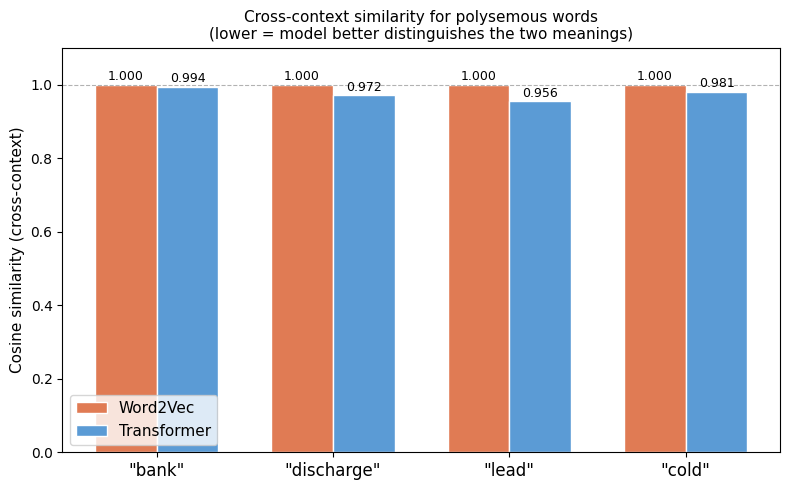

Word2Vec always returns 1.0000 — the model is completely blind to context.
Transformer produces different vectors depending on surrounding words.


In [6]:
words = list(cross_sims_w2v.keys())
x = np.arange(len(words)); w = 0.35
fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - w/2, [cross_sims_w2v[wd] for wd in words], w,
               label="Word2Vec", color="#E07B54", edgecolor="white")
bars2 = ax.bar(x + w/2, [cross_sims_tf[wd]  for wd in words], w,
               label="Transformer", color="#5B9BD5", edgecolor="white")
ax.set_xticks(x); ax.set_xticklabels([f'"{wd}"' for wd in words], fontsize=12)
ax.set_ylabel("Cosine similarity (cross-context)", fontsize=11)
ax.set_title("Cross-context similarity for polysemous words\n"
             "(lower = model better distinguishes the two meanings)", fontsize=11)
ax.set_ylim(0, 1.1); ax.axhline(1.0, color="gray", ls="--", lw=0.8, alpha=0.6)
ax.legend(fontsize=11)
for bar in list(bars1) + list(bars2):
    ax.annotate(f"{bar.get_height():.3f}",
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 3), textcoords="offset points", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig(f"{OUT}fig2_cross_context_similarity.png", dpi=150, bbox_inches="tight")
plt.show()
print("Word2Vec always returns 1.0000 — the model is completely blind to context.")
print("Transformer produces different vectors depending on surrounding words.")


## Experiment 2 — Attention Weights

We look at which tokens the word "bank" pays attention to in a financial sentence vs. a river sentence.


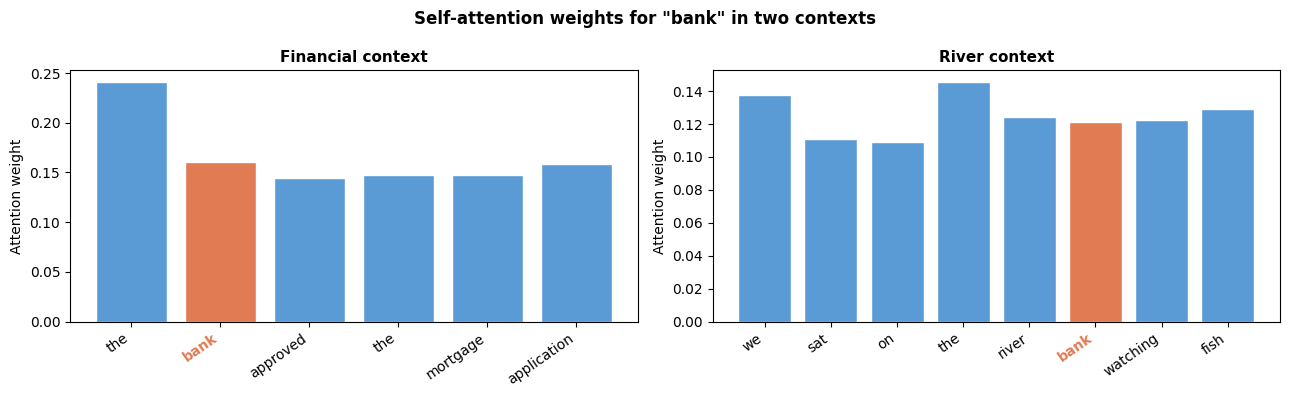

Different tokens are attended to in each context — this is what produces different embeddings.


In [7]:
bank_sentences = {
    "Financial context": "the bank approved the mortgage application",
    "River context":     "we sat on the river bank watching fish",
}

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Self-attention weights for "bank" in two contexts', fontsize=12, fontweight="bold")

for ax, (ctx_label, sent) in zip(axes, bank_sentences.items()):
    tokens = sent.lower().split()
    _, attn_w, idx = get_contextual_vec(tokens, "bank")
    bar_colors = ["#E07B54" if i == idx else "#5B9BD5" for i in range(len(tokens))]
    ax.bar(range(len(tokens)), attn_w, color=bar_colors, edgecolor="white")
    ax.set_xticks(range(len(tokens)))
    ax.set_xticklabels(tokens, rotation=35, ha="right", fontsize=10)
    ax.set_ylabel("Attention weight"); ax.set_title(ctx_label, fontsize=11, fontweight="bold")
    ax.get_xticklabels()[idx].set_color("#E07B54")
    ax.get_xticklabels()[idx].set_fontweight("bold")

plt.tight_layout()
plt.savefig(f"{OUT}fig3_attention_weights.png", dpi=150, bbox_inches="tight")
plt.show()
print("Different tokens are attended to in each context — this is what produces different embeddings.")


## Experiment 3 — PCA

We plot the word vectors in 2D. For Word2Vec both context variants of the same word sit on top of each other. For the Transformer they separate.


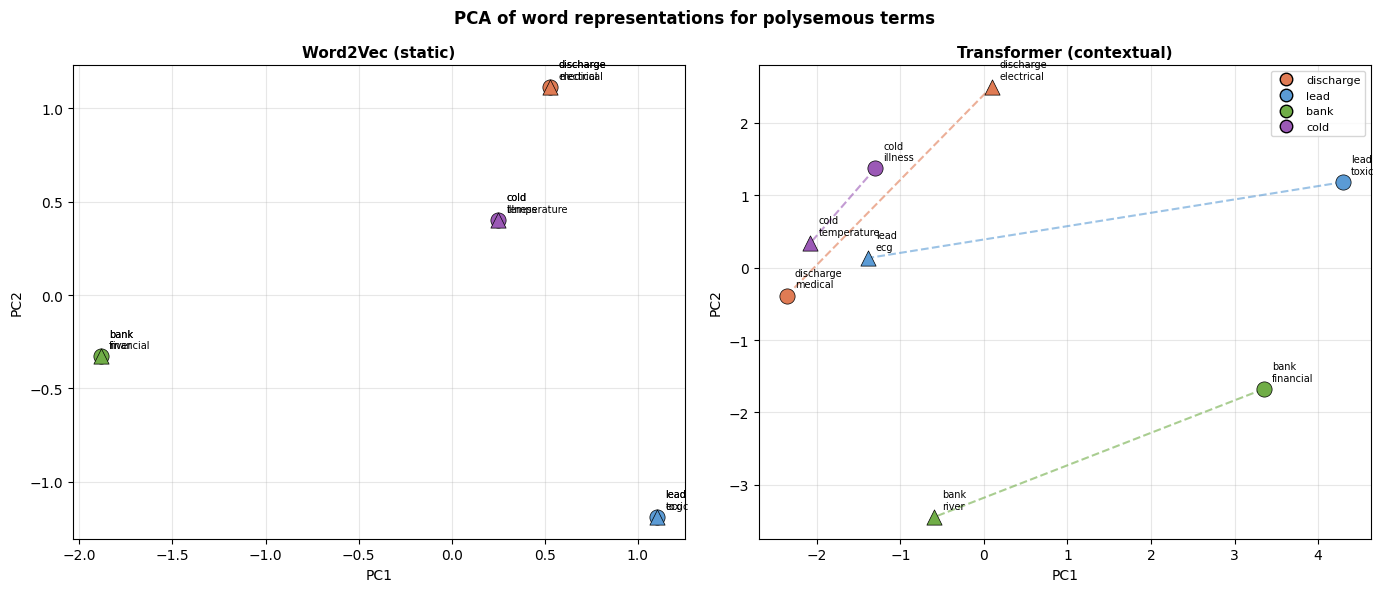

In [8]:
pca_words = ["discharge", "lead", "bank", "cold"]
pca_sentences = {
    "discharge_medical":    "the patient received a hospital discharge after surgery",
    "discharge_electrical": "the electrical discharge caused a fire",
    "lead_toxic":           "lead exposure causes serious neurological damage",
    "lead_ecg":             "the doctor attached the lead to the patient chest",
    "bank_financial":       "the bank approved the mortgage application",
    "bank_river":           "we sat on the river bank watching fish",
    "cold_illness":         "she caught a cold last week",
    "cold_temperature":     "the weather is very cold today",
}
color_map = {"discharge":"#E07B54","lead":"#5B9BD5","bank":"#70AD47","cold":"#9B59B6"}

w2v_pca_vecs, tf_pca_vecs, pca_labels = [], [], []
for label, sent in pca_sentences.items():
    word = label.split("_")[0]; tokens = sent.lower().split()
    w2v_pca_vecs.append(w2v_vec(word) if word in w2v.wv else np.zeros(DIM))
    tv, _, _ = get_contextual_vec(tokens, word)
    tf_pca_vecs.append(tv if tv is not None else np.zeros(DIM))
    pca_labels.append(label)

from sklearn.decomposition import PCA as _PCA
w2v_2d = _PCA(2, random_state=42).fit_transform(np.array(w2v_pca_vecs))
tf_2d  = _PCA(2, random_state=42).fit_transform(np.array(tf_pca_vecs))

from matplotlib.lines import Line2D
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("PCA of word representations for polysemous terms", fontsize=12, fontweight="bold")

for ax, coords, title in [(ax1, w2v_2d, "Word2Vec (static)"), (ax2, tf_2d, "Transformer (contextual)")]:
    for i, lbl in enumerate(pca_labels):
        word = lbl.split("_")[0]; ctx = lbl.split("_")[1]
        marker = "o" if ctx in ("medical","toxic","financial","illness") else "^"
        ax.scatter(coords[i,0], coords[i,1], color=color_map[word], marker=marker,
                   s=120, edgecolors="black", linewidths=0.5, zorder=3)
        ax.annotate(lbl.replace("_","\n"), (coords[i,0], coords[i,1]),
                    textcoords="offset points", xytext=(6,6), fontsize=7)
    for wd in pca_words:
        idxs = [j for j, l in enumerate(pca_labels) if l.startswith(wd+"_")]
        if len(idxs) == 2:
            ax.plot([coords[idxs[0],0], coords[idxs[1],0]],
                    [coords[idxs[0],1], coords[idxs[1],1]],
                    color=color_map[wd], lw=1.5, ls="--", alpha=0.6)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.grid(True, alpha=0.3)

legend_elems = [Line2D([0],[0],marker="o",color="w",markerfacecolor=color_map[wd],
                        markeredgecolor="black",markersize=9,label=wd) for wd in pca_words]
ax2.legend(handles=legend_elems, fontsize=8)
plt.tight_layout()
plt.savefig(f"{OUT}fig4_pca.png", dpi=150, bbox_inches="tight")
plt.show()


## Experiment 4 — Sentence Similarity

We compare sentence pairs by mean-pooling their token vectors.


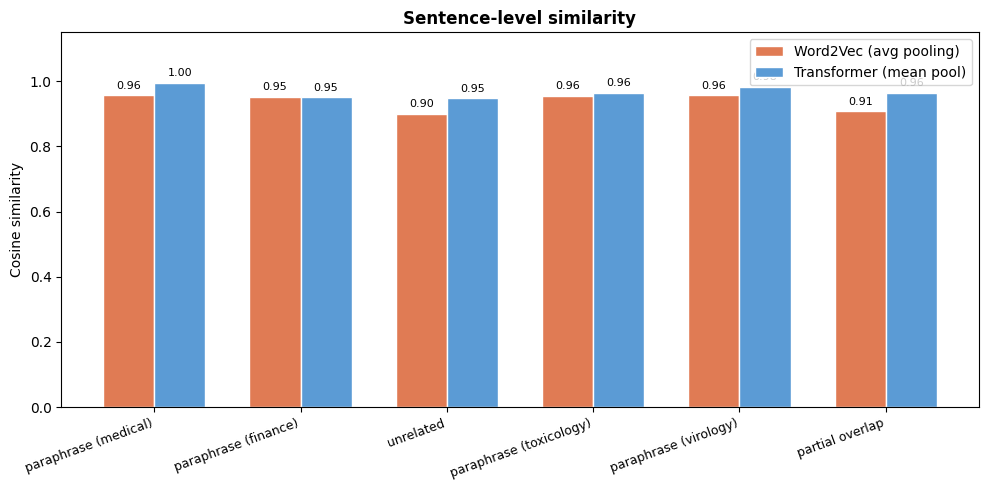

In [9]:
def sentence_w2v_vec(sent):
    tokens = [t for t in sent.lower().split() if t in w2v.wv]
    return np.mean([w2v_vec(t) for t in tokens], axis=0) if tokens else np.zeros(DIM)

def sentence_tf_vec(sent):
    tokens = sent.lower().split()
    embs, _ = transformer_encode(tokens)
    return embs.mean(0)

sentence_pairs = [
    ("patient has high fever",        "patient has elevated temperature",    "paraphrase (medical)"),
    ("the bank closed early today",   "the financial institution shut down",  "paraphrase (finance)"),
    ("the patient recovered fast",    "the bank is by the river",             "unrelated"),
    ("lead poisoning is dangerous",   "toxic metal exposure harms children",  "paraphrase (toxicology)"),
    ("cold virus spreads by air",     "rhinovirus causes common illness",     "paraphrase (virology)"),
    ("doctor signed discharge form",  "nurse left the hospital building",     "partial overlap"),
]

w2v_sent_sims, tf_sent_sims, pair_labels = [], [], []
for s1, s2, label in sentence_pairs:
    w2v_sent_sims.append(cosine_sim(sentence_w2v_vec(s1), sentence_w2v_vec(s2)))
    tf_sent_sims.append(cosine_sim(sentence_tf_vec(s1),   sentence_tf_vec(s2)))
    pair_labels.append(label)

x = np.arange(len(pair_labels)); w = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w/2, w2v_sent_sims, w, label="Word2Vec (avg pooling)", color="#E07B54", edgecolor="white")
ax.bar(x + w/2, tf_sent_sims,  w, label="Transformer (mean pool)", color="#5B9BD5", edgecolor="white")
ax.set_xticks(x); ax.set_xticklabels(pair_labels, rotation=20, ha="right", fontsize=9)
ax.set_ylabel("Cosine similarity"); ax.set_title("Sentence-level similarity", fontsize=12, fontweight="bold")
ax.set_ylim(0, 1.15); ax.legend(fontsize=10)
for i, (v1, v2) in enumerate(zip(w2v_sent_sims, tf_sent_sims)):
    ax.text(i-w/2, v1+0.02, f"{v1:.2f}", ha="center", fontsize=8)
    ax.text(i+w/2, v2+0.02, f"{v2:.2f}", ha="center", fontsize=8)
plt.tight_layout()
plt.savefig(f"{OUT}fig5_sentence_similarity.png", dpi=150, bbox_inches="tight")
plt.show()


## Experiment 5 — Negation

Both models fail here. "Patient is healthy" and "patient is NOT healthy" get ~0.99 similarity — the models can't detect negation.


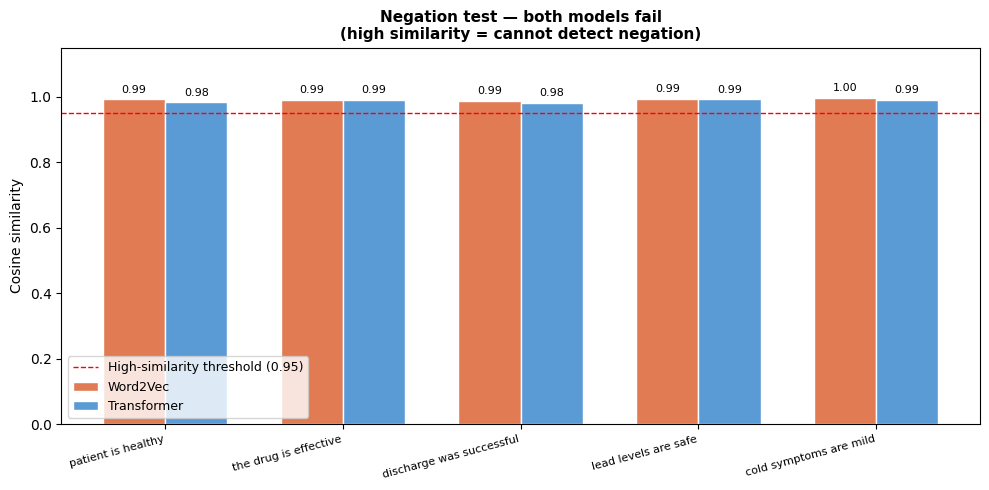

Neither model can distinguish negated from affirmative clinical statements.


In [10]:
negation_pairs = [
    ("patient is healthy",        "patient is not healthy"),
    ("the drug is effective",     "the drug is not effective"),
    ("discharge was successful",  "discharge was not successful"),
    ("lead levels are safe",      "lead levels are not safe"),
    ("cold symptoms are mild",    "cold symptoms are not mild"),
]

w2v_neg_sims, tf_neg_sims, neg_labels = [], [], []
for s1, s2 in negation_pairs:
    w2v_neg_sims.append(cosine_sim(sentence_w2v_vec(s1), sentence_w2v_vec(s2)))
    tf_neg_sims.append(cosine_sim(sentence_tf_vec(s1),   sentence_tf_vec(s2)))
    neg_labels.append(s1)

x = np.arange(len(neg_labels)); w = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x-w/2, w2v_neg_sims, w, label="Word2Vec",     color="#E07B54", edgecolor="white")
ax.bar(x+w/2, tf_neg_sims,  w, label="Transformer",  color="#5B9BD5", edgecolor="white")
ax.axhline(0.95, color="red", ls="--", lw=1, label="High-similarity threshold (0.95)")
ax.set_xticks(x); ax.set_xticklabels(neg_labels, rotation=15, ha="right", fontsize=8)
ax.set_ylabel("Cosine similarity")
ax.set_title("Negation test — both models fail\n(high similarity = cannot detect negation)",
             fontsize=11, fontweight="bold")
ax.set_ylim(0, 1.15); ax.legend(fontsize=9)
for i, (v1, v2) in enumerate(zip(w2v_neg_sims, tf_neg_sims)):
    ax.text(i-w/2, v1+0.02, f"{v1:.2f}", ha="center", fontsize=8)
    ax.text(i+w/2, v2+0.02, f"{v2:.2f}", ha="center", fontsize=8)
plt.tight_layout()
plt.savefig(f"{OUT}fig6_negation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Neither model can distinguish negated from affirmative clinical statements.")


## Bonus — Word2Vec Nearest Neighbours

The nearest neighbours of each probe word mix tokens from both its meanings, showing the model conflates them.


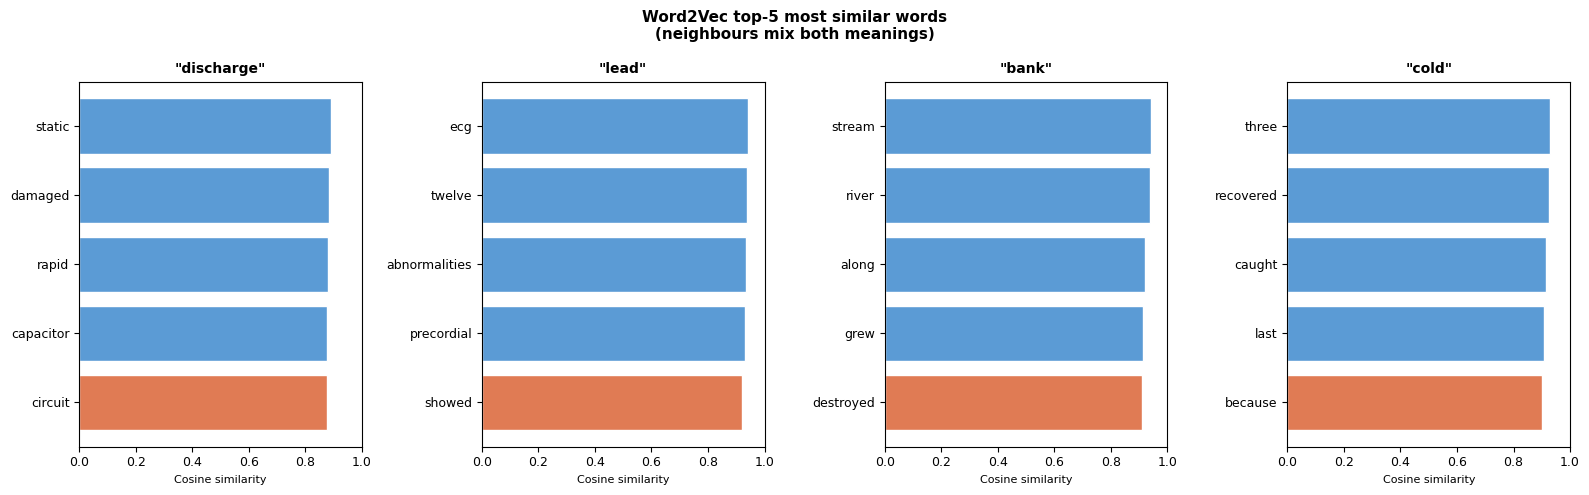

In [11]:
target_words = ["discharge", "lead", "bank", "cold"]
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.suptitle("Word2Vec top-5 most similar words\n(neighbours mix both meanings)", fontsize=11, fontweight="bold")
for ax, wd in zip(axes, target_words):
    similar = w2v.wv.most_similar(wd, topn=5)
    words_s  = [s[0] for s in similar]
    scores_s = [s[1] for s in similar]
    ax.barh(words_s[::-1], scores_s[::-1],
            color=["#E07B54"]+["#5B9BD5"]*4, edgecolor="white")
    ax.set_xlim(0, 1); ax.set_title(f'"{wd}"', fontsize=10, fontweight="bold")
    ax.set_xlabel("Cosine similarity", fontsize=8); ax.tick_params(labelsize=9)
plt.tight_layout()
plt.savefig(f"{OUT}fig7_most_similar.png", dpi=150, bbox_inches="tight")
plt.show()


## Summary

| | Word2Vec | Transformer |
|---|---|---|
| Cross-context similarity | 1.0 (same every time) | < 1.0 (context-sensitive) |
| Negation | ❌ fails | ❌ fails |

Word2Vec can't distinguish different meanings of the same word. The Transformer does a bit better, but neither handles negation. For real medical NLP you'd need something like BioBERT.
